In [1]:
import os, sys
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split as train_test_split_s
import seaborn as sns

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '../..')))
from config import *
from src.models import *
from src.dataset import *
from utils import *

# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"    # ?

set_seed(seed=GLOBAL_SEED)

gpus = tf.config.list_physical_devices('GPU')    # Динамический объем памяти
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

2025-07-25 11:43:59.079418: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-07-25 11:43:59.111025: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-25 11:43:59.552409: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT
2025-07-25 11:44:00.849360: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.

In [2]:
WINDOW_SIZE = 52
# CHANNELS = [0, 1, 2, 3, 4, 5, 6, 7]
FOLD_ID = 0

## Вспомогательные функции для предобработки датасета

> Warning: Нужно выбирать `CHANNELS` как гиперпараметр.

In [3]:
def standardize(X, means, stds):
    return (X - means[None,:,None]) / stds[None,:,None]

In [4]:
def prepare(X, channels=CHANNELS):
    Xt = np.transpose(X, (0, 2, 1))   # [N, window, channels]
    sel = Xt[..., channels]           # отбор каналов
    return sel[..., np.newaxis].astype(np.float32)

In [5]:
def train_model(model, epochs, X_train, y_train, X_valid, y_valid, batch_size=BATCH_SIZE, lr=INIT_LR, decay_rate=0.9,
                save_path=None, patience=PATIENCE):
    callbacks = [tf.keras.callbacks.EarlyStopping('val_loss', mode='min', patience=patience)]
    if save_path:
        callbacks.append(
            tf.keras.callbacks.ModelCheckpoint(
                save_path, monitor='val_loss',
                save_best_only=True, save_weights_only=False,    # Сохранять всю архитектуру
                mode='min', verbose=1
            )
        )
    steps = (len(X_train) / batch_size) * 1.5
    lr_schedule = tf.keras.optimizers.schedules.ExponentialDecay(
        lr, decay_steps=steps, decay_rate=decay_rate
    )
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr_schedule),
        loss='sparse_categorical_crossentropy', metrics=['accuracy']
    )
    return model.fit(
        X_train, y_train,
        validation_data=(X_valid, y_valid),
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1  # прогресс-бар
    )

## Парсинг данных

Данные парсятся из собранного датасета. Изменить номер фолда можно через переменную `FOLD_ID`. 

In [6]:
gestures_dict = {}

for idx in GESTURE_INDEXES_MAIN:
    gestures_dict[f'{idx}'] = np.load(f'../data/discrete_{FOLD_ID}/emg_imu_{idx}.npy')

In [7]:
emgs, labels = apply_window(gestures_dict, window=WINDOW_SIZE, step=STEP_SIZE)

## Парсинг параметров стандартизации

Средние и STDs также сохраняются в `model_finetuned/`.

In [8]:
norm_file = f'../../normalization_values/fold1_win{WINDOW_SIZE}_early_fusion_full.json'
with open(norm_file, 'r') as f: 
    old_params = json.load(f)

with open(f'../model_finetuned/fold1_win{WINDOW_SIZE}_early_fusion_full.json', 'w') as f:
    json.dump(old_params, f)

# X_stand = standardize(emgs, np.array(old_params['mean']), np.array(old_params['std']))
X_input = prepare(emgs, channels=range(emgs.shape[1]))

Здесь стоит обратить внимание на средние и отклонения собранного датасета и примерно оценить, насколько эти данные отличаются от обучающего корпуса.

In [9]:
print(np.mean(X_input, axis=(0, 1, 3)))    # Проверка средних и стандартных отклонений для собранных данных
print(np.std(X_input, axis=(0, 1, 3)))

[-7.4522430e-01 -8.6611444e-01 -8.5183859e-01 -8.6325926e-01
 -8.1618100e-01 -7.6227850e-01 -6.2092853e-01 -7.5257349e-01
 -5.2061060e+02  1.9079055e+03  3.1899899e+02]
[  5.602084  14.013516  22.77105   17.781515  17.273283  15.924433
  21.31655   10.39945  176.45746  155.29169  422.51212 ]


## Компиляция модели

In [10]:
input_shape = (WINDOW_SIZE, emgs.shape[1], 1)
print(input_shape)
# model = build_base_model(input_shape, FILTERS_BASE, KERNEL_SIZE_BASE, POOL_SIZE_BASE, P_DROPOUT_BASE, NUM_CLASSES)
# model.load_weights('../../' + SAVE_PATH + f'_fold1_{WINDOW_SIZE}_early_fusion_full.h5')

# model.trainable = False
# for layer in model.layers:
#     if isinstance(layer, tf.keras.layers.BatchNormalization):
#         layer.trainable = False  # это критично!


# inp = layers.Input(shape=input_shape)

# # Адаптационный слой
# x = layers.Conv2D(1, (1, 1), padding='same', name='adapt_layer')(inp)

# # Пропуск через базовую модель
# out = model(x)

# # Итоговая модель
# model = Model(inputs=inp, outputs=out)

# 1. Загружаем базовую модель и её веса
base_model = build_base_fusion_model(input_shape, FILTERS_BASE, KERNEL_SIZE_BASE, POOL_SIZE_BASE, P_DROPOUT_BASE, NUM_CLASSES)
base_model.load_weights('../../' + SAVE_PATH + f'_fold1_{WINDOW_SIZE}_early_fusion_full.h5')

# 2. Замораживаем ВСЁ и отдельно отключаем trainable у всех BatchNorm-слоёв
base_model.trainable = False
for layer in base_model.layers:
    # если слой сам — BN
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False
    # если это вложенная модель/Sequential, то надо пройти по её слоям
    if isinstance(layer, Model):
        for sub in layer.layers:
            if isinstance(sub, layers.BatchNormalization):
                sub.trainable = False

# (опционально) проверяем
for layer in base_model.layers:
    print(f"{layer.name:<30} trainable={layer.trainable}")

# 3. Строим адаптированную модель на Functional API
inp = layers.Input(shape=input_shape)
x = layers.Conv2D(1, (1,1), padding='same', name='adapt_layer')(inp)
out = base_model(x)
model = Model(inputs=inp, outputs=out)

# 4. Делаем trainable=True только для нашего адаптационного слоя
for layer in model.layers:
    layer.trainable = (layer.name == 'adapt_layer')

(52, 11, 1)
conv2d                         trainable=False
batch_normalization            trainable=False
p_re_lu                        trainable=False
spatial_dropout2d              trainable=False
max_pooling2d                  trainable=False
conv2d_1                       trainable=False
batch_normalization_1          trainable=False
p_re_lu_1                      trainable=False
spatial_dropout2d_1            trainable=False
max_pooling2d_1                trainable=False
flatten                        trainable=False
dense                          trainable=False
softmax                        trainable=False


2025-07-25 11:44:01.160285: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-25 11:44:01.163878: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2025-07-25 11:44:01.166610: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:996] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysf

Для модели с пространственным (`SAM`) и канальным (`CAM`) вниманием рекомендуется заморозить слои для избежания недообучения из за нехватки данных: 

In [11]:
# model.layers[9].trainable = False    # Заморозка пространственного внимания в SAM

А затем проверить список активных слоев.

Для `SAM` модели должна быть строчка `spatial_attention: trainable = False`:

In [12]:
# model.layers[0].trainable = False 
for layer in model.layers:
    print(f"{layer.name}: trainable = {layer.trainable}")

input_2: trainable = False
adapt_layer: trainable = True
sequential: trainable = False


## Оценка предобученной модели

In [13]:
f1_score_real, report_real, conf_matrix_real = evaluate_metrics(model, X_input, labels, batch_size=BATCH_SIZE)

2025-07-25 11:44:01.982295: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1502,52,11,1]
	 [[{{node Placeholder/_10}}]]
2025-07-25 11:44:01.982431: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [1502,52,11,1]
	 [[{{node Placeholder/_10}}]]


6/6 [==============================] - 1s 6ms/step


2025-07-25 11:44:02.644381: I tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:637] TensorFloat-32 will be used for the matrix multiplication. This will only be logged once.
2025-07-25 11:44:02.662279: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:424] Loaded cuDNN version 8901


In [14]:
print(f'F1 score: {f1_score_real}')

F1 score: 0.021971540219715403


In [15]:
for g in list(report_real.keys())[:-3]:
    print(f'Gesture #{g}')
    print('F1 score: ', report_real[g]['f1-score'])
    print('Precision: ', report_real[g]['precision'])
    print('Recall: ', report_real[g]['recall'])

Gesture #0
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #1
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #2
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #3
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #4
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #5
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #6
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #7
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #8
F1 score:  0.19774386197743862
Precision:  0.10972017673048601
Recall:  1.0


<Axes: >

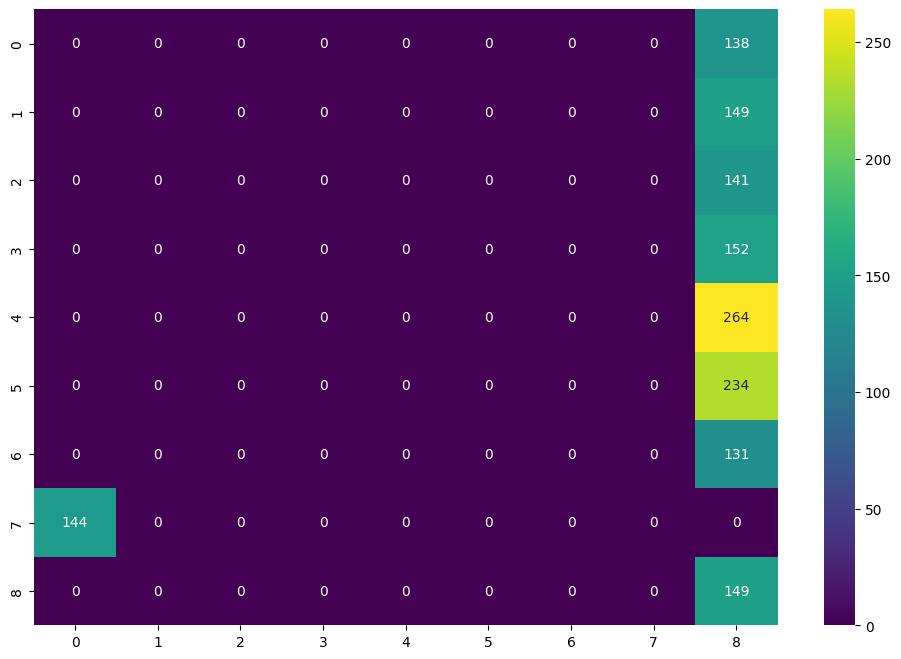

In [16]:
plt.figure(figsize=(12, 8))  # ширина=10, высота=6 дюймов
sns.heatmap(conf_matrix_real, cmap='viridis', annot=True, fmt=".0f")

## Дообучение

При подготовке данных надо сделать перестандартизацию - сначала стандартизировать оригинальные данные (пересчитать среднее и стандартные отклонения на тренировочном датасете), а затем привести с старой шкале:

In [17]:
X_train, X_test, y_train, y_test = train_test_split_s(X_input, labels.reshape(-1, 1), test_size=0.3, stratify=labels, random_state=42)

In [18]:
new_means = X_train.mean(axis=(0, 2))       # (channels,)
new_stds  = X_train.std(axis=(0, 2)) + 1e-8

X_train = standardize(X_train, new_means, new_stds)    # Стандартизация по новым параметрам
X_test = standardize(X_test, new_means, new_stds)

# X_train = standardize(X_train, np.array(old_params['mean']), np.array(old_params['std']))    # Стандартизация по старым параметрам
# X_test = standardize(X_test, np.array(old_params['mean']), np.array(old_params['std']))

In [19]:
print(np.mean(X_input, axis=(0, 1, 3)))    # Проверка средних и стандартных отклонений для собранных данных
print(np.std(X_input, axis=(0, 1, 3)))

[-7.4522430e-01 -8.6611444e-01 -8.5183859e-01 -8.6325926e-01
 -8.1618100e-01 -7.6227850e-01 -6.2092853e-01 -7.5257349e-01
 -5.2061060e+02  1.9079055e+03  3.1899899e+02]
[  5.602084  14.013516  22.77105   17.781515  17.273283  15.924433
  21.31655   10.39945  176.45746  155.29169  422.51212 ]


In [20]:
f1_score_real, report_real, conf_matrix_real = evaluate_metrics(model, X_test, y_test, batch_size=BATCH_SIZE)

2/2 [==============================] - 0s 11ms/step


2025-07-25 11:44:03.104128: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [451,52,11,1]
	 [[{{node Placeholder/_10}}]]
2025-07-25 11:44:03.104263: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [451,52,11,1]
	 [[{{node Placeholder/_10}}]]


In [21]:
f1_score_real

0.022075055187637967

Для дообучения надо ставить низкий темп обучения (lr, размер батча), чтобы предотвратить разрушение претрейновых параметров и стабилизировать градиенты.

In [22]:
weights_path = '../model_finetuned/weights.h5'   
train_model(model, 500, X_train=X_train, y_train=y_train, lr=1e-2, X_valid=X_test, y_valid=y_test, 
            batch_size=16, save_path=weights_path) 

Epoch 1/500


2025-07-25 11:44:03.189952: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [1051,1]
	 [[{{node Placeholder/_11}}]]
2025-07-25 11:44:03.190111: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [1051,1]
	 [[{{node Placeholder/_11}}]]
2025-07-25 11:44:03.580444: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inmodel/sequential/spatial_dropout2d/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer
2025-07-25 11:44:03.6604

UnimplementedError: Graph execution error:

Detected at node 'gradient_tape/model/sequential/batch_normalization_1/FusedBatchNormGradV3' defined at (most recent call last):
    File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "/home/etri3060/1_CNN_gestures/LightCBAM_HGR/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "/home/etri3060/1_CNN_gestures/LightCBAM_HGR/.venv/lib/python3.10/site-packages/traitlets/config/application.py", line 1075, in launch_instance
      app.start()
    File "/home/etri3060/1_CNN_gestures/LightCBAM_HGR/.venv/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 739, in start
      self.io_loop.start()
    File "/home/etri3060/1_CNN_gestures/LightCBAM_HGR/.venv/lib/python3.10/site-packages/tornado/platform/asyncio.

## Оценка дообученной модели

In [ ]:
model.load_weights(weights_path)

In [ ]:
f1_score_real, report_real, conf_matrix_real = evaluate_metrics(model, X_test, y_test)

2/2 [==============================] - 0s 5ms/step


2025-07-25 11:31:27.552733: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [451,52,11,1]
	 [[{{node Placeholder/_10}}]]
2025-07-25 11:31:27.552883: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_10' with dtype float and shape [451,52,11,1]
	 [[{{node Placeholder/_10}}]]


In [ ]:
print(f'F1 score: {f1_score_real}')

F1 score: 0.7539539360321861


In [ ]:
model.evaluate(X_test, y_test)

15/15 [==============================] - 0s 2ms/step - loss: 0.6898 - accuracy: 0.7716


2025-07-25 11:31:27.655458: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [451,1]
	 [[{{node Placeholder/_11}}]]
2025-07-25 11:31:27.655608: I tensorflow/core/common_runtime/executor.cc:1197] [/device:CPU:0] (DEBUG INFO) Executor start aborting (this does not indicate an error and you can ignore this message): INVALID_ARGUMENT: You must feed a value for placeholder tensor 'Placeholder/_11' with dtype int64 and shape [451,1]
	 [[{{node Placeholder/_11}}]]


[0.6897737979888916, 0.7716186046600342]

In [ ]:
for g in list(report_real.keys())[:-3]:
    print(f'Gesture #{g}')
    print('F1 score: ', report_real[g]['f1-score'])
    print('Precision: ', report_real[g]['precision'])
    print('Recall: ', report_real[g]['recall'])

Gesture #0
F1 score:  0.9523809523809523
Precision:  0.9523809523809523
Recall:  0.9523809523809523
Gesture #1
F1 score:  0.76
Precision:  0.6909090909090909
Recall:  0.8444444444444444
Gesture #2
F1 score:  0.0
Precision:  0.0
Recall:  0.0
Gesture #3
F1 score:  0.9425287356321839
Precision:  1.0
Recall:  0.8913043478260869
Gesture #4
F1 score:  0.6048780487804878
Precision:  0.49206349206349204
Recall:  0.7848101265822784
Gesture #5
F1 score:  0.7368421052631579
Precision:  0.9545454545454546
Recall:  0.6
Gesture #6
F1 score:  0.8705882352941177
Precision:  0.8043478260869565
Recall:  0.9487179487179487
Gesture #7
F1 score:  1.0
Precision:  1.0
Recall:  1.0
Gesture #8
F1 score:  0.9183673469387755
Precision:  0.8490566037735849
Recall:  1.0


<Axes: >

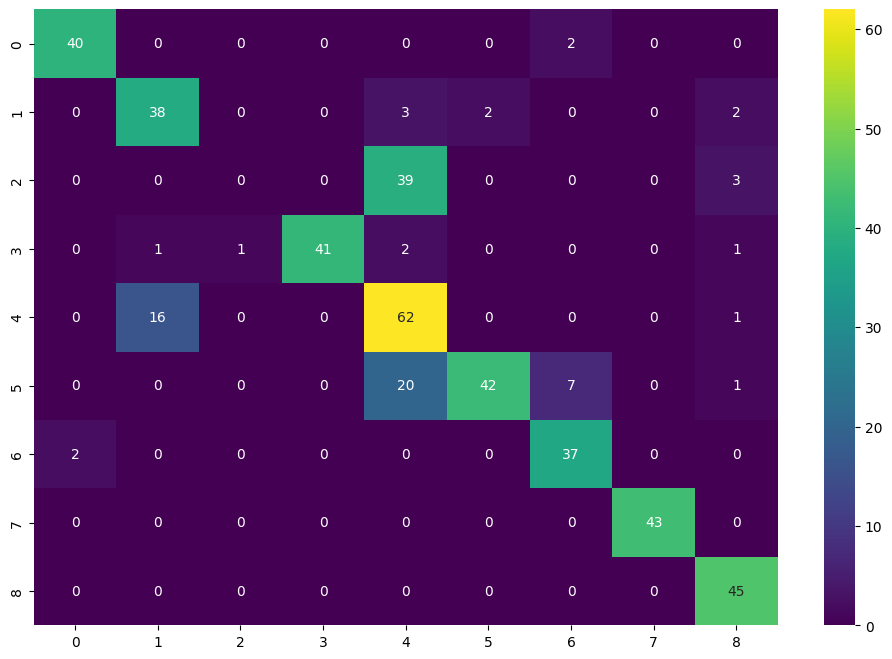

In [ ]:
plt.figure(figsize=(12, 8))  # ширина=10, высота=6 дюймов
sns.heatmap(conf_matrix_real, cmap='viridis', annot=True, fmt=".0f")